In [100]:
import ase.io
import nglview as nv
import matplotlib.pyplot as plt
from ase.io import read
from get_calc import get_uma_calc

In [102]:

file_path_train = '/data/ishan-amin/OMOL/electrolytes_application/xyz_data/NAPF6/s1p1/train/train_frames.xyz'
file_path_val = '/data/ishan-amin/OMOL/electrolytes_application/xyz_data/NAPF6/s1p1/val/val_frames.xyz'
file_path_og = '/data/ishan-amin/OMOL/electrolytes_application/npt_trajs_distillation/npt_trajs_napf6_dme_uma_omol/s1p1/md_omol_re5_small_1p1_wrapped.traj'

molecules_val = read(file_path_val, index=":")
molecules_train = read(file_path_train, index=":")
molecules_og = read(file_path_og, index=":")

In [106]:
t = nv.ASETrajectory(molecules_train)
w = nv.NGLWidget(t)
w.add_spacefill(radiusType="vdw", radiusScale=0.5)
w

NGLWidget(max_frame=2459)

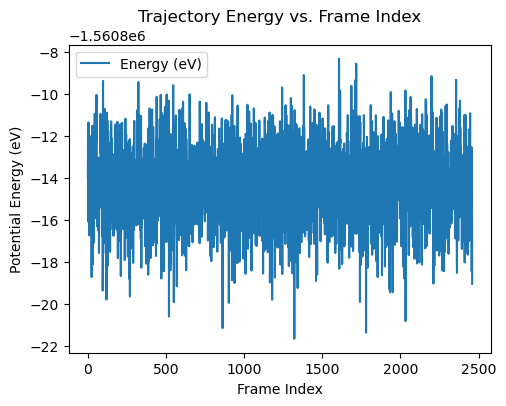

: 

In [ ]:
plot_efs(molecules_train)

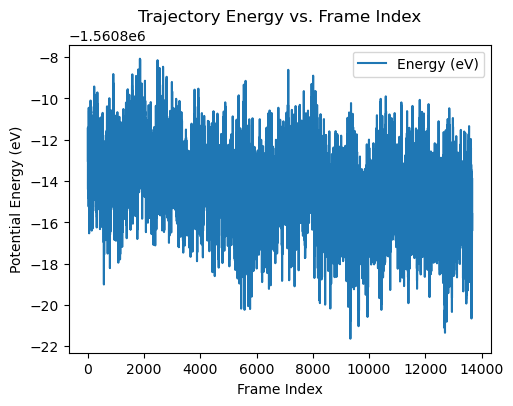

In [90]:
plot_efs(molecules_og)

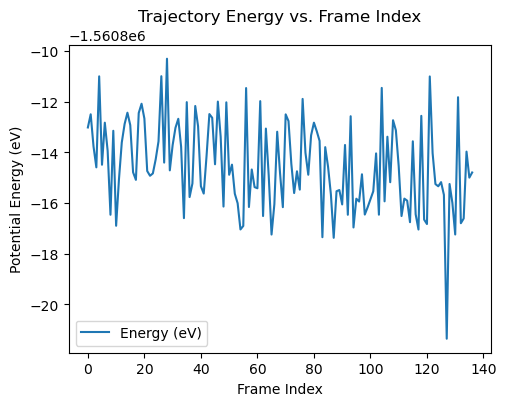

In [88]:
plot_efs(molecules_og[::100])

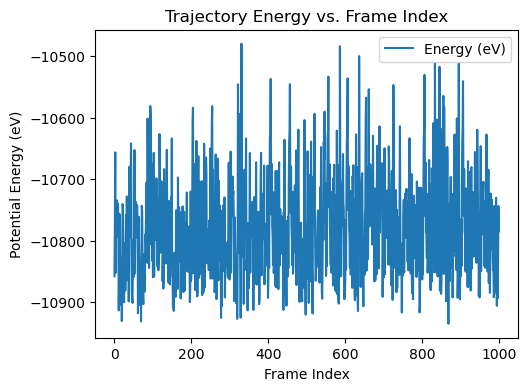

In [89]:
plot_efs(molecules_train)

In [60]:
calc = get_uma_calc()

atoms = molecules_train[0]

# To get the total charge on the atoms object, use:
# (ASE Atoms does not have a built-in 'charge' attribute by default, but it may be set in atoms.info or atoms.charge)
# Check common locations for charge information:

print(atoms.get_potential_energy())
atoms.info['charge'] = int(atoms.info['charge'])
atoms.info['spin'] = int(atoms.info['spin'])
print("Charge on atoms:", atoms.info['charge'])

# If you want to set the charge (e.g., for calculators that require it), you can do:
# atoms.charge = 0  # or whatever integer value is appropriate

atoms.calc = calc
print(atoms.get_total_energy())


-1560813.017970012
Charge on atoms: 0
-1560730.165435975


In [44]:
def plot_efs(traj):
    energies = [atoms.get_potential_energy() for atoms in traj]
    forces_norm = [atoms.get_forces().std() for atoms in traj]  # Example: std of forces per frame
    stresses = [atoms.get_stress().mean() for atoms in traj]
    indices = list(range(len(traj)))
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(indices, energies, label='Energy (eV)')
    plt.xlabel('Frame Index')
    plt.ylabel('Potential Energy (eV)')
    plt.title('Trajectory Energy vs. Frame Index')
    plt.legend()

    # plt.subplot(1, 2, 2)
    # plt.plot(indices, forces_norm, label='Forces std (eV/Å)')
    # plt.xlabel('Frame Index')
    # plt.ylabel('Std of Forces (eV/Å)')
    # plt.title('Trajectory Forces Std vs. Frame Index')
    # plt.legend()
    
    # plt.figure()
    # plt.plot(indices, stresses, label='Mean Stress')
    # plt.xlabel('Frame Index')
    # plt.ylabel('Mean Stress')
    # plt.title('Trajectory Mean Stress vs. Frame Index')
    # plt.legend()
    
    # plt.tight_layout()
    # plt.show()
    
    

In [80]:
plot_efs(molecules_val)

TypeError: Invalid type for charge: <class 'numpy.int64'>. Charge must be an integer representing the total charge on the system.

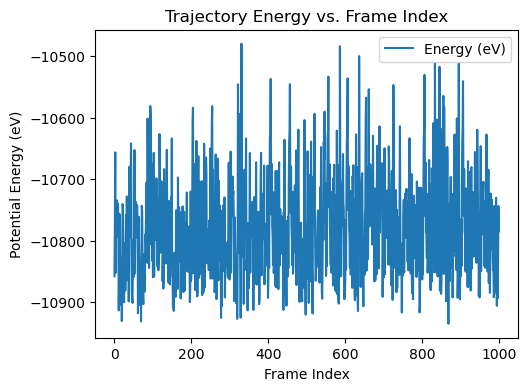

In [46]:
plot_efs(molecules_train)

In [29]:



# Get the first molecule in the list
first_mol = molecules[0]

# for atoms in molecules:
#     print(atoms.info.get('energy'))      # Per-frame energy
#     print(atoms.arrays.get('forces'))    # Per-atom forces
#     print(atoms.info.get('stress')) 
    
energy = first_mol.get_potential_energy()
forces = first_mol.get_forces()
stress = first_mol.get_stress()

print("Energy:", energy)
print("Energy 2:", first_mol.calc.results['energy'])
print("Forces (2nd atom):", forces)
print("Stress:", stress)

Energy: -1560814.7942303875
Energy 2: -1560814.7942303875
Forces (2nd atom): [[ 3.41186400e-02 -3.65269480e-01 -2.09440690e-01]
 [ 5.16849700e-01  5.97090360e-01  1.09311450e+00]
 [-1.35996437e+00 -4.08961860e-01  7.43463340e-01]
 ...
 [-3.16773000e-01 -5.68944600e-02 -3.16883650e-01]
 [ 6.02880000e-04 -5.96579790e-01  1.85217770e-01]
 [-3.68720470e-01  5.80962180e-01  5.07641970e-01]]
Stress: [ 0.00185058  0.00106476  0.00115332 -0.00073169  0.00092554 -0.00083934]


Mean energy of trajectory: -10781.647346738448


In [91]:

# Read the trajectory using ASE
file_path = '/data/ishan-amin/OMOL/electrolytes_application/trajs/md_omol_re5_medium_new_1p1.traj'
traj = ase.io.read(file_path, index=":")
print(len(traj))

# Print the cell for the first frame
print("Cell of first frame:")
print(traj[0].cell)

num_atoms_first_frame = len(traj[0])
print(f"Number of atoms in the first frame: {num_atoms_first_frame}")

t = nv.ASETrajectory(traj)
w = nv.NGLWidget(t)
w.add_spacefill(radiusType="vdw", radiusScale=0.5)
w


1894
Cell of first frame:
Cell([28.5579, 28.5579, 28.5579])
Number of atoms in the first frame: 2136


NGLWidget(max_frame=1893)

In [3]:
print(traj[101])

Atoms(symbols='C500H1250F102Na17O250P17', pbc=True, cell=[29.21772231237912, 28.575528421936973, 28.708999765793433], momenta=..., calculator=SinglePointCalculator(...))
